# 02 - Preprocessing: baseline wander removal

Goal: implement the first preprocessing block of the paper. The raw abdominal ECG `S1` is filtered with a high-pass FIR filter to obtain `S2`, where slow baseline drift is attenuated.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
from data_io import load_record
from preprocessing import remove_baseline_wander
from plotting import plot_baseline_removal_comparison, plot_filter_response


## Load raw signal S1

`S1` is the original 4-channel abdominal ECG from PhysioNet. At this point no filtering has been applied.

In [2]:
record = load_record('a14')
S1 = record.signals

print(f'Record: {record.name}')
print(f'S1 shape: {S1.shape}  # samples x channels')
print(f'Sampling frequency: {record.fs:.0f} Hz')
print(f'Duration: {record.time[-1]:.2f} s')


Record: a14
S1 shape: (60000, 4)  # samples x channels
Sampling frequency: 1000 Hz
Duration: 60.00 s


## Apply baseline wander removal

We use a zero-phase high-pass FIR filter with cutoff `3 Hz`. Zero-phase filtering is useful because later we will compare QRS positions in time.

In [3]:
baseline_result = remove_baseline_wander(
    S1,
    fs=record.fs,
    cutoff_hz=3.0,
    numtaps=1001,
)
S2 = baseline_result.filtered_signals

print(f'S2 shape: {S2.shape}')
print(f'Cutoff: {baseline_result.cutoff_hz} Hz')
print(f'FIR taps used: {len(baseline_result.taps)}')


S2 shape: (60000, 4)
Cutoff: 3.0 Hz
FIR taps used: 1001


## Filter response

This figure verifies that very low frequencies are attenuated. The red dashed line marks the selected cutoff frequency.

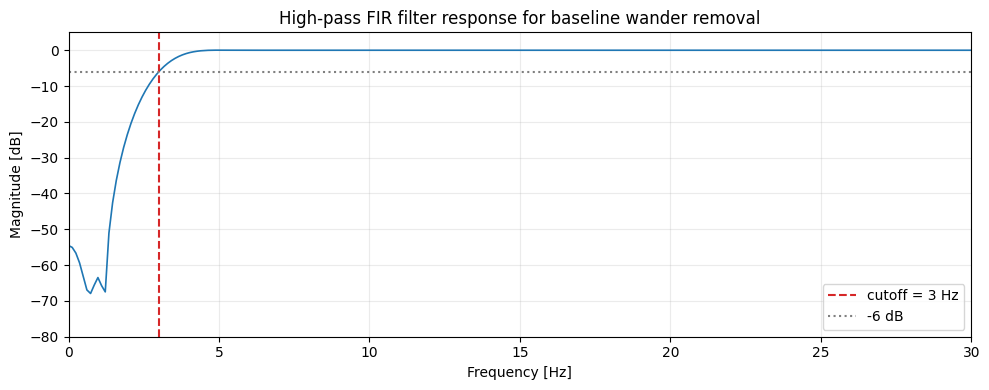

In [4]:
fig, ax = plot_filter_response(
    baseline_result.taps,
    fs=baseline_result.fs,
    cutoff_hz=baseline_result.cutoff_hz,
    save_path=PROJECT_ROOT / 'figures' / 'notebook02' / 'a14_baseline_highpass_response.png',
)
plt.show()


## S1 vs S2, first 10 seconds

The gray line is the raw signal `S1`; the blue line is `S2` after baseline wander removal. This zoom is useful to check that ECG morphology is still visible.

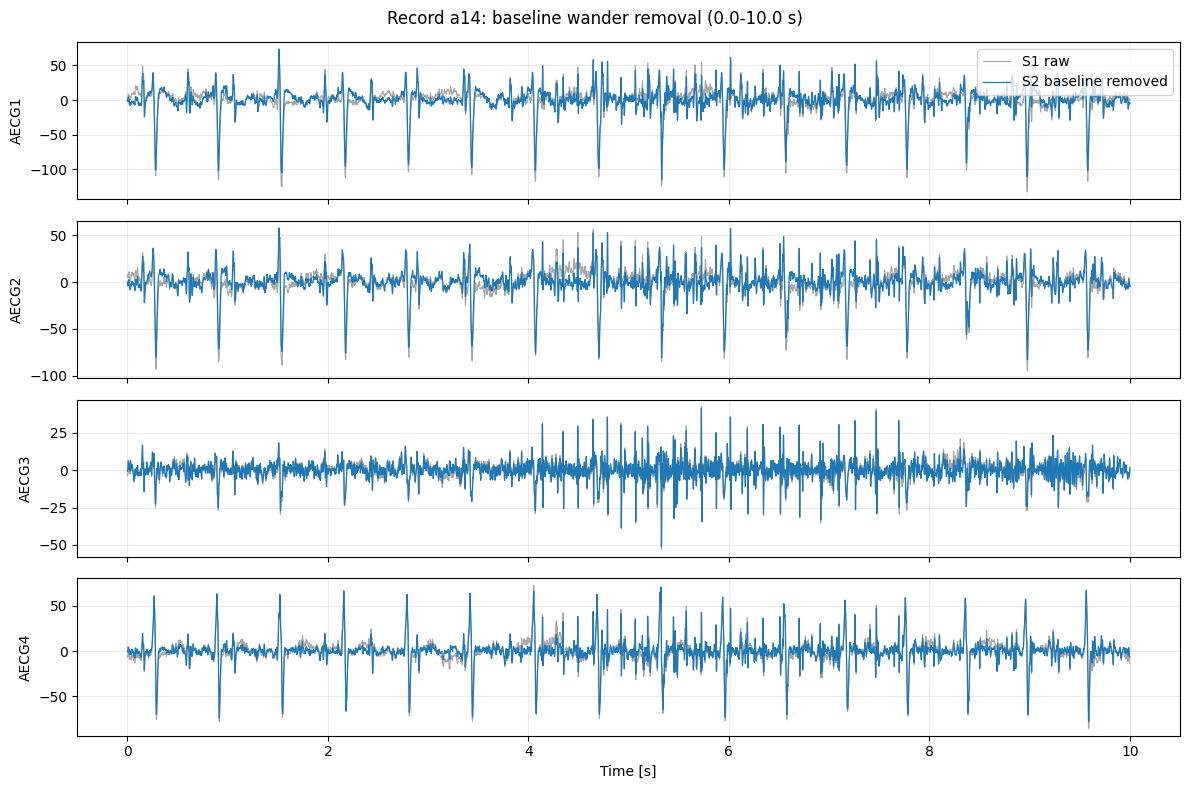

In [5]:
fig, axes = plot_baseline_removal_comparison(
    record,
    S2,
    seconds=(0, 10),
    save_path=PROJECT_ROOT / 'figures' / 'notebook02' / 'a14_s1_s2_baseline_comparison_0_10s.png',
)
plt.show()


## S1 vs S2, full record

The full-record view is denser, but it shows the reduction of slow baseline drift across the whole 60 seconds.

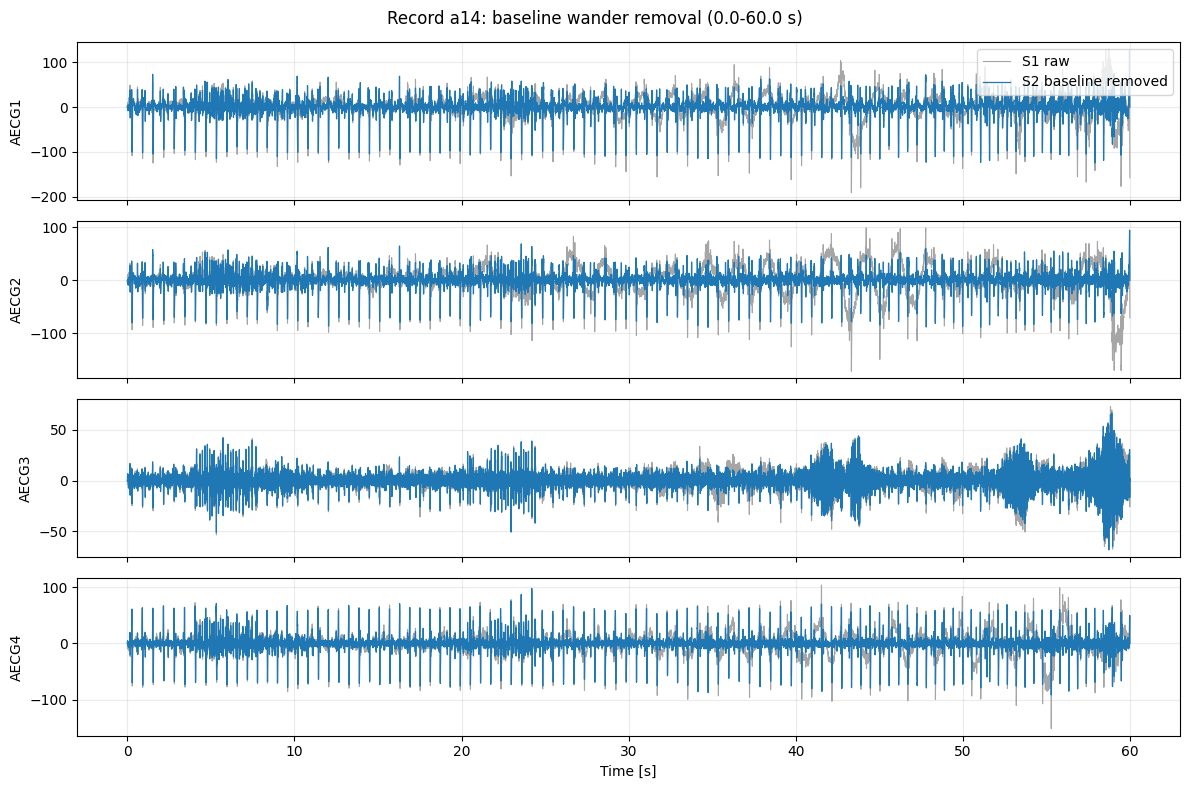

In [6]:
fig, axes = plot_baseline_removal_comparison(
    record,
    S2,
    seconds=(0, record.time[-1]),
    save_path=PROJECT_ROOT / 'figures' / 'notebook02' / 'a14_s1_s2_baseline_comparison_full.png',
)
plt.show()


## Output of this step

`S2` is the baseline-corrected ECG signal. The next preprocessing step is power-line interference cancellation, which will produce `S3`.